# 04 — Improvements: V2 Pipeline → V3 Experiments


Measures the impact of three targeted improvements over the baseline enriched pipeline:

| # | Improvement | Change | Rationale |
|---|-------------|--------|-----------|
| 1 | **Cyclic time encoding** | Replace 14 month/quarter dummies with 4 sin/cos features | Correct seasonal adjacency; Dec ↔ Jan are close, not opposite |
| 2 | **Current-month holidays** | Remove t-1 lag from holiday features | Holidays are known calendar facts — no leakage at time t |
| 3 | **Country-level hierarchy** | Add leave-one-out country aggregate (t-1) | National conflict context; approximates a hierarchical prior |

**Evaluation**: 5 models × 6 feature sets × 3 targets × top-10 regions = 900 evaluations, 6-month holdout.

**Comparison**: V1 ablation results (already on disk) vs V2 ablation results (run below).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')  # run from forecast_model/ so relative data paths work

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from utils.preprocessing_v2 import prepare_enriched_pipeline_v2, build_feature_sets_v2
from utils.ablation import MODELS
from utils.evaluators import find_top_regions, evaluate_model
from config import settings

print('Imports OK')

Imports OK


## 1. Build V2 Dataset

Rebuilds from raw data with all three improvements applied.
Cached to `data/processed/model_data_v2_enriched.csv` — pass `clean_data=True` to force rebuild.

In [2]:
df_v2 = prepare_enriched_pipeline_v2(clean_data=False)

print(f'\nV2 dataset: {df_v2.shape[0]:,} rows × {df_v2.shape[1]} columns')

# Verify new features are present
checks = {
    'Cyclic months':    ['month_sin', 'month_cos', 'quarter_sin', 'quarter_cos'],
    'No-lag holidays':  ['holiday_count_month', 'is_holiday_month'],
    'Country features': ['country_battles_excl (t-1)', 'country_remote_excl (t-1)',
                         'country_vac_excl (t-1)', 'country_total_excl (t-1)'],
    'Dummies removed':  ['month_2', 'quarter_2'],
    'Lag holidays gone':['n_holidays_lag1', 'is_holiday_month_lag1'],
}

print('\nFeature presence check:')
for label, cols in checks.items():
    present = [c for c in cols if c in df_v2.columns]
    absent  = [c for c in cols if c not in df_v2.columns]
    if label in ('Dummies removed', 'Lag holidays gone'):
        status = 'OK (absent)' if not present else f'WARN — still present: {present}'
    else:
        status = f'OK ({len(present)}/{len(cols)})' if present else f'MISSING: {absent}'
    print(f'  {label:20s}: {status}')

Loading v2 enriched data from disk...



V2 dataset: 289,890 rows × 78 columns

Feature presence check:
  Cyclic months       : OK (4/4)
  No-lag holidays     : OK (2/2)
  Country features    : OK (4/4)
  Dummies removed     : OK (absent)
  Lag holidays gone   : OK (absent)


## 2. Run V2 Ablation (900 evaluations)

6 feature sets × 5 models × 3 targets × 10 regions. The extra tier vs V1 is **+Country**.

In [3]:
feature_sets_v2 = build_feature_sets_v2(df_v2)
top_regions     = find_top_regions(df_v2, settings.targets, n=10)

print('V2 feature sets:')
for name, cols in feature_sets_v2.items():
    print(f'  {name:12s}: {len(cols)} features')

print(f'\nTop-10 regions: {top_regions}')

V2 feature sets:
  Baseline    : 20 features
  +Risk       : 27 features
  +Macro      : 31 features
  +Holidays   : 33 features
  +Country    : 37 features
  +Engineered : 46 features

Top-10 regions: ['UKR - Donetsk', 'UKR - Kharkiv', 'UKR - Sumy', 'SYR - Idlib', 'PSX - Gaza', 'UKR - Kherson', 'BRA - Rio de Janeiro', 'SYR - Aleppo', 'UKR - Zaporizhzhia', 'UKR - Luhansk']


In [4]:
combos = list(iproduct(MODELS.keys(), feature_sets_v2.keys(), settings.targets, top_regions))
print(f'Running {len(combos)} V2 evaluations '
      f'({len(MODELS)} models × {len(feature_sets_v2)} feature sets × '
      f'{len(settings.targets)} targets × {len(top_regions)} regions)...')

records_v2 = []
for i, (model_name, fs_name, target, region) in enumerate(combos):
    result = evaluate_model(
        df_v2, region, target,
        feature_sets_v2[fs_name],
        MODELS[model_name],
        holdout=6,
    )
    if result is not None:
        records_v2.append({'model': model_name, 'feature_set': fs_name,
                           'target': target, 'region': region, **result})
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(combos)} done...')

ablation_v2 = pd.DataFrame(records_v2)
os.makedirs('outputs', exist_ok=True)
ablation_v2.to_csv('outputs/ablation_results_v2.csv', index=False)
print(f'Done. {len(records_v2)} results. Saved to outputs/ablation_results_v2.csv')

Running 900 V2 evaluations (5 models × 6 feature sets × 3 targets × 10 regions)...


  100/900 done...


  200/900 done...


  300/900 done...


  400/900 done...


  500/900 done...


  600/900 done...


  700/900 done...


  800/900 done...


  900/900 done...
Done. 900 results. Saved to outputs/ablation_results_v2.csv


## 3. V2 Ablation Results

In [5]:
fs_names_v2 = list(feature_sets_v2.keys())

print('=' * 80)
print('V2 MEAN MAE — ALL REGIONS + TARGETS COMBINED')
print('=' * 80)
pivot_v2_all = (
    ablation_v2.groupby(['model', 'feature_set'])['mae']
    .mean().unstack('feature_set')[fs_names_v2].round(2)
)
print(pivot_v2_all.to_string())

print('\n' + '=' * 80)
print('V2 PER-TARGET BREAKDOWN')
print('=' * 80)
for target in settings.targets:
    sub = ablation_v2[ablation_v2['target'] == target]
    pivot_t = (
        sub.groupby(['model', 'feature_set'])['mae']
        .mean().unstack('feature_set').reindex(columns=fs_names_v2).round(2)
    )
    print(f'\nTarget: {target}')
    print(pivot_t.to_string())

V2 MEAN MAE — ALL REGIONS + TARGETS COMBINED
feature_set   Baseline  +Risk  +Macro  +Holidays  +Country  +Engineered
model                                                                  
GBR              64.25  65.17   67.00      65.90     69.47        63.73
LGBM-Poisson     55.64  55.84   55.78      55.85     56.83        56.71
LGBM-Tweedie     56.84  56.94   57.62      57.59     53.05        53.60
RF               58.98  59.10   60.48      59.43     60.11        60.08
XGBoost          63.84  63.22   63.17      63.40     64.10        60.56

V2 PER-TARGET BREAKDOWN

Target: Battles
feature_set   Baseline  +Risk  +Macro  +Holidays  +Country  +Engineered
model                                                                  
GBR              65.52  67.15   66.08      65.64     71.24        56.34
LGBM-Poisson     48.56  48.82   48.74      48.83     49.73        50.67
LGBM-Tweedie     49.84  50.14   50.27      50.39     47.50        50.94
RF               58.08  57.47   60.04      58.53 

## 4. V1 vs V2 — Head-to-Head Comparison

Compares the **best feature set** from each pipeline across all models and targets.
V1 best = `+Engineered` (5 tiers). V2 best = `+Engineered` (6 tiers, includes +Country).

In [6]:
ablation_v1 = pd.read_csv('outputs/ablation_results.csv')

# Extract best feature set from each pipeline
v1_best = ablation_v1[ablation_v1['feature_set'] == '+Engineered'].copy()
v2_best = ablation_v2[ablation_v2['feature_set'] == '+Engineered'].copy()

v1_mean = v1_best.groupby('model')['mae'].mean().rename('V1 +Engineered')
v2_mean = v2_best.groupby('model')['mae'].mean().rename('V2 +Engineered')

comparison = pd.concat([v1_mean, v2_mean], axis=1).round(2)
comparison['Delta (V2 - V1)'] = (comparison['V2 +Engineered'] - comparison['V1 +Engineered']).round(2)
comparison['% Change'] = ((comparison['Delta (V2 - V1)'] / comparison['V1 +Engineered']) * 100).round(1)

print('Head-to-head: V1 +Engineered vs V2 +Engineered (mean MAE, all targets + regions)')
print(comparison.to_string())
print('\nNegative Delta = V2 is better (lower MAE)')

Head-to-head: V1 +Engineered vs V2 +Engineered (mean MAE, all targets + regions)
              V1 +Engineered  V2 +Engineered  Delta (V2 - V1)  % Change
model                                                                  
GBR                    61.42           63.73             2.31       3.8
LGBM-Poisson           53.20           56.71             3.51       6.6
LGBM-Tweedie           57.73           53.60            -4.13      -7.2
RF                     57.37           60.08             2.71       4.7
XGBoost                60.41           60.56             0.15       0.2

Negative Delta = V2 is better (lower MAE)


In [7]:
print('Per-target comparison (V1 vs V2 +Engineered, RF and LGBM-Poisson):')
print()

for target in settings.targets:
    v1_t = v1_best[v1_best['target'] == target].groupby('model')['mae'].mean()
    v2_t = v2_best[v2_best['target'] == target].groupby('model')['mae'].mean()
    tbl = pd.concat([v1_t.rename('V1'), v2_t.rename('V2')], axis=1).round(2)
    tbl['Δ']  = (tbl['V2'] - tbl['V1']).round(2)
    tbl['%']  = ((tbl['Δ'] / tbl['V1']) * 100).round(1)
    print(f'--- {target} ---')
    print(tbl.to_string())
    print()

Per-target comparison (V1 vs V2 +Engineered, RF and LGBM-Poisson):

--- Battles ---
                 V1     V2     Δ    %
model                                
GBR           57.13  56.34 -0.79 -1.4
LGBM-Poisson  51.28  50.67 -0.61 -1.2
LGBM-Tweedie  50.52  50.94  0.42  0.8
RF            54.34  57.33  2.99  5.5
XGBoost       49.62  51.11  1.49  3.0

--- Explosions/Remote violence ---
                  V1      V2      Δ     %
model                                    
GBR           121.76  129.36   7.60   6.2
LGBM-Poisson  103.44  114.54  11.10  10.7
LGBM-Tweedie  117.80  105.05 -12.75 -10.8
RF            112.74  117.82   5.08   4.5
XGBoost       126.24  125.60  -0.64  -0.5

--- Violence against civilians ---
                V1    V2     Δ    %
model                              
GBR           5.37  5.48  0.11  2.0
LGBM-Poisson  4.89  4.91  0.02  0.4
LGBM-Tweedie  4.88  4.82 -0.06 -1.2
RF            5.03  5.08  0.05  1.0
XGBoost       5.37  4.97 -0.40 -7.4



## 5. Per-Improvement Breakdown (V2 incremental gains)

Each improvement's marginal contribution is visible in the step-by-step feature set addition.
V1 reference: `Baseline → +Risk → +Macro → +Holidays → +Engineered` (RF only, for clarity).

In [8]:
rf_v1 = ablation_v1[ablation_v1['model'] == 'RF']
rf_v2 = ablation_v2[ablation_v2['model'] == 'RF']

v1_steps = ['Baseline', '+Risk', '+Macro', '+Holidays', '+Engineered']
v2_steps = ['Baseline', '+Risk', '+Macro', '+Holidays', '+Country', '+Engineered']

v1_rf_means = rf_v1.groupby('feature_set')['mae'].mean().reindex(v1_steps).round(2)
v2_rf_means = rf_v2.groupby('feature_set')['mae'].mean().reindex(v2_steps).round(2)

print('RF MAE at each feature tier (mean over all targets + regions):')
print()
print(f"{'Feature set':15s}  {'V1 MAE':>8s}  {'V2 MAE':>8s}  {'V2 Δ vs prev':>14s}")
print('-' * 55)

prev = None
for fs in v2_steps:
    v1_val = v1_rf_means.get(fs, float('nan'))
    v2_val = v2_rf_means.get(fs, float('nan'))
    delta_str = ''
    if prev is not None and not np.isnan(v2_val) and not np.isnan(prev):
        delta = v2_val - prev
        delta_str = f'{delta:+.2f} ({delta/prev*100:+.1f}%)'
    v1_str = f'{v1_val:.2f}' if not np.isnan(v1_val) else '  —  '
    print(f'{fs:15s}  {v1_str:>8s}  {v2_val:>8.2f}  {delta_str:>14s}')
    prev = v2_val

RF MAE at each feature tier (mean over all targets + regions):

Feature set        V1 MAE    V2 MAE    V2 Δ vs prev
-------------------------------------------------------
Baseline            57.25     58.98                
+Risk               57.95     59.10   +0.12 (+0.2%)
+Macro              56.64     60.48   +1.38 (+2.3%)
+Holidays           57.12     59.43   -1.05 (-1.7%)
+Country              —       60.11   +0.68 (+1.1%)
+Engineered         57.37     60.08   -0.03 (-0.0%)


## 6. Visualization — V1 vs V2 MAE Heatmaps

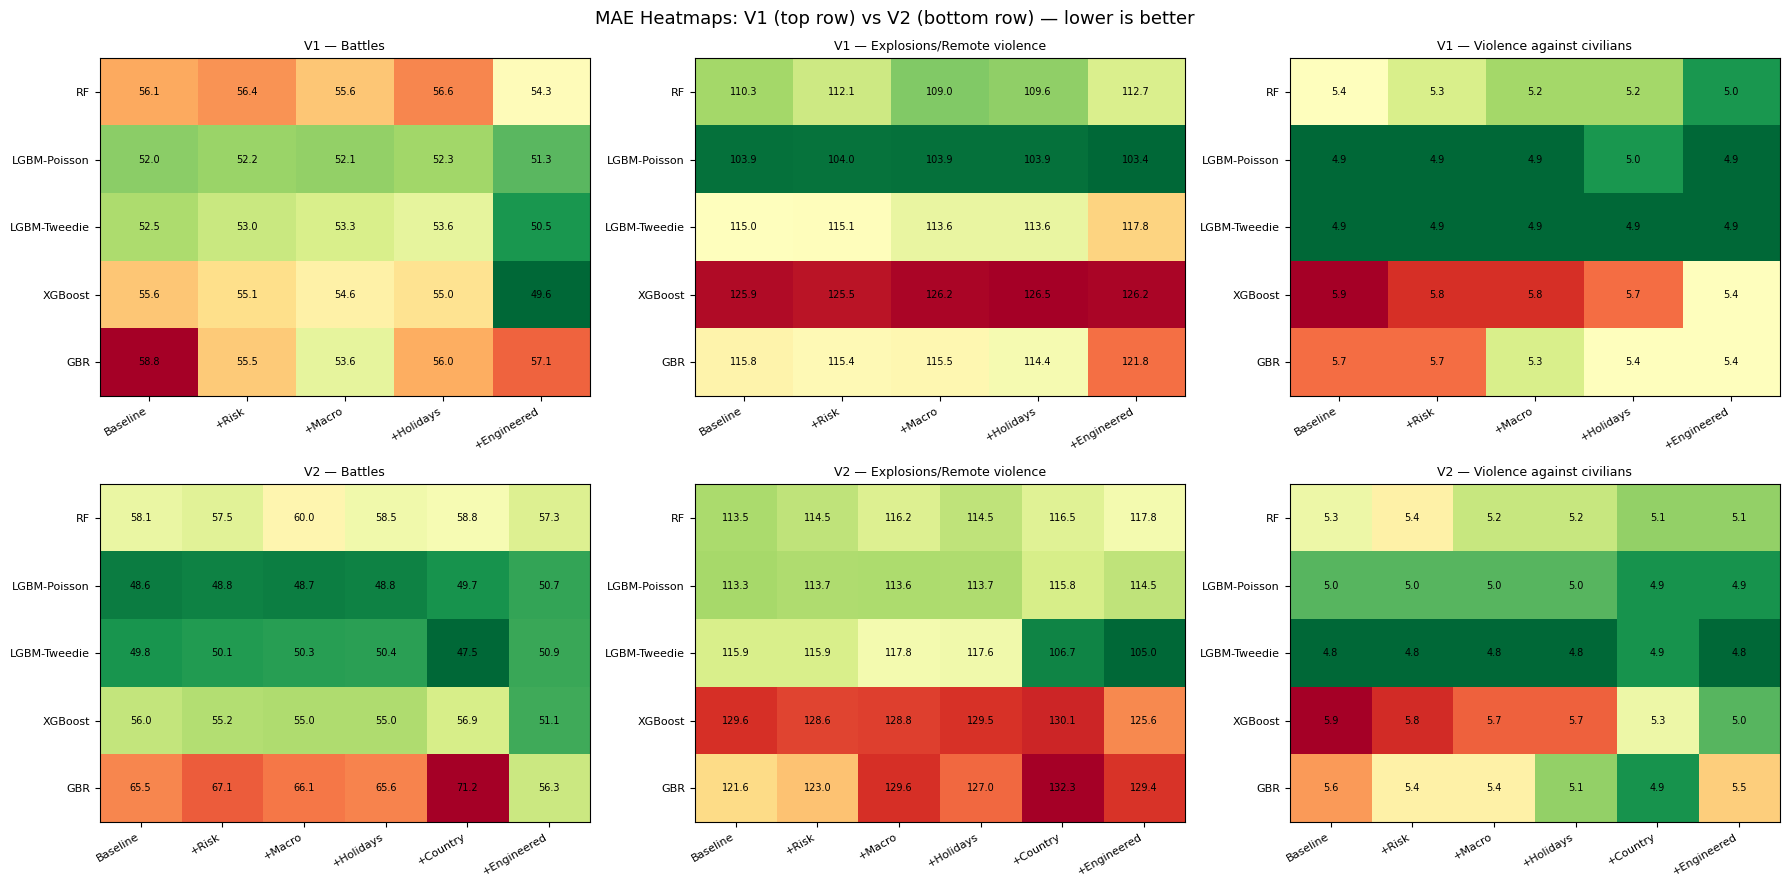

Saved: outputs/figures/v1_vs_v2_heatmaps.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('MAE Heatmaps: V1 (top row) vs V2 (bottom row) — lower is better', fontsize=13)

model_order = ['RF', 'LGBM-Poisson', 'LGBM-Tweedie', 'XGBoost', 'GBR']

for col_idx, target in enumerate(settings.targets):
    # V1
    sub_v1 = ablation_v1[ablation_v1['target'] == target]
    piv_v1 = (
        sub_v1.groupby(['model', 'feature_set'])['mae'].mean()
        .unstack('feature_set')[['Baseline', '+Risk', '+Macro', '+Holidays', '+Engineered']]
        .reindex(model_order).round(1)
    )
    ax = axes[0, col_idx]
    im = ax.imshow(piv_v1.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(piv_v1.columns)))
    ax.set_xticklabels(piv_v1.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(piv_v1.index)))
    ax.set_yticklabels(piv_v1.index, fontsize=8)
    ax.set_title(f'V1 — {target}', fontsize=9)
    for r in range(piv_v1.shape[0]):
        for c in range(piv_v1.shape[1]):
            ax.text(c, r, f'{piv_v1.values[r, c]:.1f}', ha='center', va='center', fontsize=7)

    # V2
    sub_v2 = ablation_v2[ablation_v2['target'] == target]
    piv_v2 = (
        sub_v2.groupby(['model', 'feature_set'])['mae'].mean()
        .unstack('feature_set')[fs_names_v2]
        .reindex(model_order).round(1)
    )
    ax = axes[1, col_idx]
    ax.imshow(piv_v2.values, aspect='auto', cmap='RdYlGn_r')
    ax.set_xticks(range(len(piv_v2.columns)))
    ax.set_xticklabels(piv_v2.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(piv_v2.index)))
    ax.set_yticklabels(piv_v2.index, fontsize=8)
    ax.set_title(f'V2 — {target}', fontsize=9)
    for r in range(piv_v2.shape[0]):
        for c in range(piv_v2.shape[1]):
            ax.text(c, r, f'{piv_v2.values[r, c]:.1f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/v1_vs_v2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/v1_vs_v2_heatmaps.png')

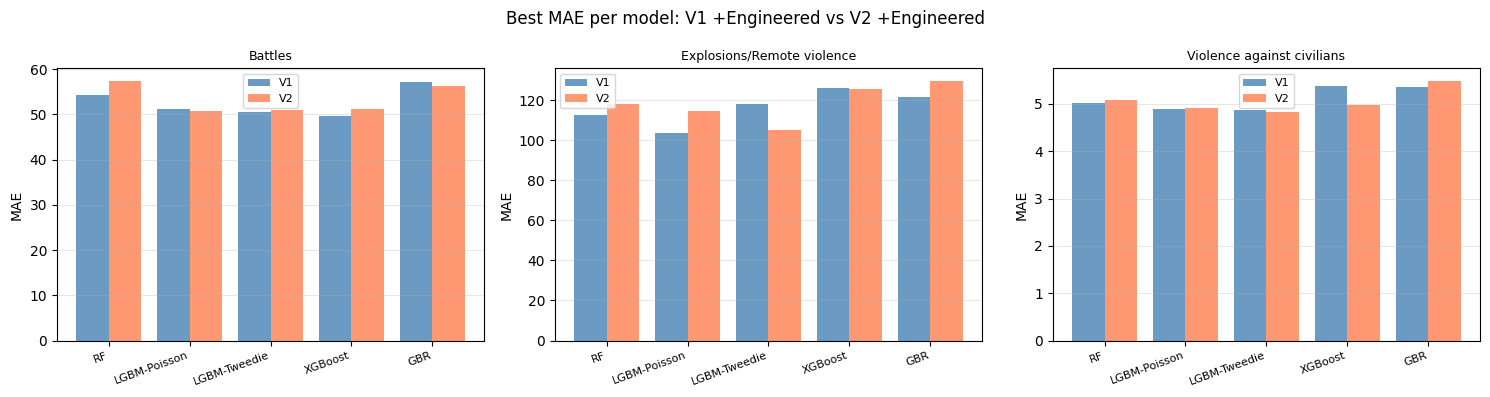

Saved: outputs/figures/v1_vs_v2_bar.png


In [10]:
# Bar chart: V1 vs V2 best-combo MAE per target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Best MAE per model: V1 +Engineered vs V2 +Engineered', fontsize=12)

for ax, target in zip(axes, settings.targets):
    v1_t = (ablation_v1[(ablation_v1['feature_set'] == '+Engineered') &
                         (ablation_v1['target'] == target)]
            .groupby('model')['mae'].mean().reindex(model_order))
    v2_t = (ablation_v2[(ablation_v2['feature_set'] == '+Engineered') &
                         (ablation_v2['target'] == target)]
            .groupby('model')['mae'].mean().reindex(model_order))

    x = np.arange(len(model_order))
    ax.bar(x - 0.2, v1_t.values, width=0.4, label='V1', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, v2_t.values, width=0.4, label='V2', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=20, ha='right', fontsize=8)
    ax.set_title(target, fontsize=9)
    ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/v1_vs_v2_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/v1_vs_v2_bar.png')

## 7. Summary

Key numbers printed below for quick reference.

In [11]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)

# Overall best for each pipeline
for label, abl in [('V1', ablation_v1), ('V2', ablation_v2)]:
    best_row = abl.groupby(['model', 'feature_set'])['mae'].mean().idxmin()
    best_val = abl.groupby(['model', 'feature_set'])['mae'].mean().min()
    rf_base  = abl[(abl['model'] == 'RF') & (abl['feature_set'] == 'Baseline')]['mae'].mean()
    pct      = (best_val - rf_base) / rf_base * 100
    print(f'{label} best: model={best_row[0]}, feature_set={best_row[1]}')
    print(f'     MAE={best_val:.2f}  (RF Baseline: {rf_base:.2f},  {pct:+.1f}%)')

print()
print('V1 vs V2 overall improvement (best combo each):')
v1_best_val = ablation_v1.groupby(['model', 'feature_set'])['mae'].mean().min()
v2_best_val = ablation_v2.groupby(['model', 'feature_set'])['mae'].mean().min()
delta_pct   = (v2_best_val - v1_best_val) / v1_best_val * 100
print(f'  V1 best MAE: {v1_best_val:.2f}')
print(f'  V2 best MAE: {v2_best_val:.2f}')
print(f'  Change:      {delta_pct:+.1f}%  ({'improvement' if delta_pct < 0 else 'regression'})')

print()
print('Country hierarchy marginal impact (RF, mean over all targets + regions):')
rf_holidays = ablation_v2[(ablation_v2['model'] == 'RF') & (ablation_v2['feature_set'] == '+Holidays')]['mae'].mean()
rf_country  = ablation_v2[(ablation_v2['model'] == 'RF') & (ablation_v2['feature_set'] == '+Country')]['mae'].mean()
print(f'  +Holidays → +Country: {rf_country - rf_holidays:+.2f} MAE  ({(rf_country - rf_holidays)/rf_holidays*100:+.1f}%)')

SUMMARY
V1 best: model=LGBM-Poisson, feature_set=+Engineered
     MAE=53.20  (RF Baseline: 57.25,  -7.1%)
V2 best: model=LGBM-Tweedie, feature_set=+Country
     MAE=53.05  (RF Baseline: 58.98,  -10.1%)

V1 vs V2 overall improvement (best combo each):
  V1 best MAE: 53.20
  V2 best MAE: 53.05
  Change:      -0.3%  (improvement)

Country hierarchy marginal impact (RF, mean over all targets + regions):
  +Holidays → +Country: +0.68 MAE  (+1.1%)


---
# V3: Six-Step Benchmark (Multi-output, Encoding, Delta)


# Six-Step Enhancement Benchmark — V3

| # | Step | Description |
|---|------|-------------|
| 0 | **Persistence baseline** | Naive Y(t) = Y(t-1) — reference for all improvements |
| 1 | **Combined multi-output** | Single `RegressorChain` predicting all 3 targets jointly |
| 2 | **Improved feature encoding** | log1p on count predictors + label-encode religion strings |
| 3 | **Shifted delta — unlock Poisson/Tweedie** | Shift ΔY by constant → all-non-negative; enables count models on delta |
| 4 | **Religion-weighted holiday score** | Weight each religion's holiday count by country religious composition |
| 5 | **All models on change-in-target** | Full 5-model benchmark predicting ΔY (shifted), reconstructed to absolute |
| 6 | **Combined: multi-output + encoding on delta** | RegressorChain + log1p encoding predicting all 3 ΔY simultaneously |

**Baseline for all comparisons**: persistence model MAE (Y(t) = Y(t-1)).
**Feature set**: V2 `+Engineered` (best from improvements_5.ipynb) unless noted.

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
pass  # chdir removed (already set by first setup cell)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iproduct

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import RegressorChain, MultiOutputRegressor

from utils.preprocessing_v2 import prepare_enriched_pipeline_v2, build_feature_sets_v2
from utils.ablation import MODELS
from utils.evaluators import find_top_regions, evaluate_model
from utils.features.encoding import (
    encode_religion_columns, apply_log_transforms, add_religion_weighted_holidays
)
from utils.features.improved_features import PREDICTORS_V2, COUNTRY_FEATURES, HOLIDAY_FEATURES_V2
from config import settings

HOLDOUT = 6
TOP_N   = 10
print('Imports OK')

Imports OK


In [13]:
df = prepare_enriched_pipeline_v2(clean_data=False)
top_regions    = find_top_regions(df, settings.targets, n=TOP_N)
feature_sets   = build_feature_sets_v2(df)
BEST_FEATURES  = feature_sets['+Engineered']   # V2 best feature set

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Top regions: {top_regions}')
print(f'Best feature set size: {len(BEST_FEATURES)} features')

Loading v2 enriched data from disk...


Dataset: 289,890 rows × 78 columns
Top regions: ['UKR - Donetsk', 'UKR - Kharkiv', 'UKR - Sumy', 'SYR - Idlib', 'PSX - Gaza', 'UKR - Kherson', 'BRA - Rio de Janeiro', 'SYR - Aleppo', 'UKR - Zaporizhzhia', 'UKR - Luhansk']
Best feature set size: 46 features


---
## Step 0: Persistence Baseline

Naive model: predict Y(t) = Y(t−1).  All subsequent improvements are judged
against this floor — any ML model that cannot beat this is useless.

In [14]:
def persistence_evaluate(df, region, target, holdout=HOLDOUT):
    rdf = df[df['matched_admin1_id'] == region].sort_values('month_year')
    if len(rdf) < holdout + 6:
        return None
    test    = rdf.iloc[-holdout:]
    lag_col = f'{target} (t-1)'
    if lag_col not in test.columns:
        return None
    y_test = test[target].fillna(0).values
    y_pred = test[lag_col].fillna(0).values
    mae    = mean_absolute_error(y_test, y_pred)
    nz     = y_test != 0
    mape   = (np.mean(np.abs((y_test[nz] - y_pred[nz]) / y_test[nz])) * 100
              if nz.any() else np.nan)
    return {'mae': round(mae, 2), 'mape': round(mape, 2) if not np.isnan(mape) else np.nan}

persist_records = []
for target, region in iproduct(settings.targets, top_regions):
    r = persistence_evaluate(df, region, target)
    if r:
        persist_records.append({'model': 'Persistence', 'target': target,
                                 'region': region, **r})

persist_df = pd.DataFrame(persist_records)

print('=' * 60)
print('PERSISTENCE BASELINE — mean MAE over top-10 regions')
print('=' * 60)
per_target = persist_df.groupby('target')['mae'].mean().round(2)
print(per_target.to_string())
print(f'\nOverall (all targets): {persist_df["mae"].mean():.2f}')

PERSISTENCE BASELINE — mean MAE over top-10 regions
target
Battles                       45.84
Explosions/Remote violence    88.33
Violence against civilians     3.60

Overall (all targets): 45.92


---
## Step 1: Combined Multi-Output Model (RegressorChain)

`RegressorChain` trains models sequentially:
- **Battles** → fit on features only
- **Explosions** → fit on features + predicted Battles
- **VaC** → fit on features + predicted Battles + predicted Explosions

This lets downstream targets exploit cross-target correlations that 3 independent
models miss.  Base estimator: LGBM-Tweedie (best single-target model from V2).

In [15]:
def evaluate_chain(df, region, predictors, chain_factory,
                   targets=settings.targets, holdout=HOLDOUT):
    """Train a RegressorChain and return per-target MAE."""
    rdf = df[df['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None
    avail   = [p for p in predictors if p in rdf.columns]
    train   = rdf.iloc[:-holdout]
    test    = rdf.iloc[-holdout:]
    X_train = train[avail].fillna(0)
    X_test  = test[avail].fillna(0)
    Y_train = train[targets].fillna(0)
    Y_test  = test[targets].fillna(0)
    weights = train.get('importance_weight',
                        pd.Series(1.0, index=train.index)).fillna(1)
    model = chain_factory()
    try:
        model.fit(X_train, Y_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, Y_train)
    Y_pred = np.maximum(0, model.predict(X_test))
    return {t: round(mean_absolute_error(Y_test[t], Y_pred[:, i]), 2)
            for i, t in enumerate(targets)}

tweedie_base = lambda: lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=200, verbose=-1)
chain_factory   = lambda: RegressorChain(tweedie_base())
indep_factory   = lambda: MultiOutputRegressor(tweedie_base())

print('Running Step 1 — RegressorChain vs Independent models...')
chain_records, indep_records = [], []

for region in top_regions:
    rc = evaluate_chain(df, region, BEST_FEATURES, chain_factory)
    ri = evaluate_chain(df, region, BEST_FEATURES, indep_factory)
    if rc and ri:
        for t in settings.targets:
            chain_records.append({'model': 'RegressorChain', 'region': region,
                                   'target': t, 'mae': rc[t]})
            indep_records.append({'model': 'Independent×3', 'region': region,
                                   'target': t, 'mae': ri[t]})

chain_df = pd.DataFrame(chain_records + indep_records)
print('Done.')

Running Step 1 — RegressorChain vs Independent models...


Done.


In [16]:
persist_means = persist_df.groupby('target')['mae'].mean()
chain_means   = pd.DataFrame(chain_records).groupby('target')['mae'].mean()
indep_means   = pd.DataFrame(indep_records).groupby('target')['mae'].mean()

step1 = pd.DataFrame({
    'Persistence': persist_means,
    'Independent×3 (Tweedie)': indep_means,
    'RegressorChain (Tweedie)': chain_means,
}).round(2)
step1['Chain vs Persist %'] = ((step1['RegressorChain (Tweedie)'] - step1['Persistence'])
                                / step1['Persistence'] * 100).round(1)
step1['Chain vs Indep %']   = ((step1['RegressorChain (Tweedie)'] - step1['Independent×3 (Tweedie)'])
                                / step1['Independent×3 (Tweedie)'] * 100).round(1)

print('=' * 72)
print('STEP 1 — Combined Multi-Output (mean MAE, top-10 regions)')
print('=' * 72)
print(step1.to_string())

overall_persist = persist_df['mae'].mean()
overall_chain   = pd.DataFrame(chain_records)['mae'].mean()
overall_indep   = pd.DataFrame(indep_records)['mae'].mean()
print(f'\nOverall  Persistence:    {overall_persist:.2f}')
print(f'Overall  Independent×3:  {overall_indep:.2f}  ({(overall_indep-overall_persist)/overall_persist*100:+.1f}% vs persist)')
print(f'Overall  RegressorChain: {overall_chain:.2f}  ({(overall_chain-overall_persist)/overall_persist*100:+.1f}% vs persist)')
print('\nNegative = better than reference')

STEP 1 — Combined Multi-Output (mean MAE, top-10 regions)
                            Persistence  Independent×3 (Tweedie)  RegressorChain (Tweedie)  Chain vs Persist %  Chain vs Indep %
target                                                                                                                          
Battles                           45.84                    50.98                     50.98                11.2               0.0
Explosions/Remote violence        88.33                   108.91                    111.53                26.3               2.4
Violence against civilians         3.60                     4.63                      4.53                25.8              -2.2

Overall  Persistence:    45.92
Overall  Independent×3:  54.84  (+19.4% vs persist)
Overall  RegressorChain: 55.68  (+21.2% vs persist)

Negative = better than reference


---
## Step 2: Improved Feature Encoding

Two fixes applied to the V2 feature set:

1. **log1p on count predictors** — ACLED event counts are zero-heavy and
   right-skewed (most regions ~0, a few have 1000+). log1p compresses the
   tail and makes tree splits more informative.

2. **LabelEncode religion columns** — `majority_religion` etc. contain WRP
   string codes (e.g. `'islmsunpct'`).  These are stored as object dtype and
   silently become NaN in sklearn's array conversion.  Label-encoding converts
   them to integers that all models can actually use.

Religion features were present in `df` but **not in any V2 feature set** —
this step also adds them to the predictor list.

In [17]:
# Build encoded dataframe
df_enc, log_col_map = apply_log_transforms(encode_religion_columns(df))

print(f'log1p columns added: {len(log_col_map)}')
print('Sample mappings:', list(log_col_map.items())[:4])

# Verify religion encoding
print()
for c in ['majority_religion', 'minority1_religion', 'minority2_religion']:
    vals = df_enc[c].dropna().unique()[:5]
    print(f'  {c}: dtype={df_enc[c].dtype}, sample={vals}')

log1p columns added: 33
Sample mappings: [('Battles (t-1)', 'log1p_Battles (t-1)'), ('Explosions/Remote violence (t-1)', 'log1p_Explosions/Remote violence (t-1)'), ('Protests (t-1)', 'log1p_Protests (t-1)'), ('Riots (t-1)', 'log1p_Riots (t-1)')]

  majority_religion: dtype=int64, sample=[-1 16  6  7  9]
  minority1_religion: dtype=int64, sample=[-1 15  9 18 11]
  minority2_religion: dtype=int64, sample=[-1 14  0  6  8]


In [18]:
RELIGION_FEATS = [
    'majority_religion', 'majority_pct',
    'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct',
    'nonreligpct',
]

def encode_feature_list(feat_list, col_map):
    """Replace count cols with their log1p versions; keep everything else."""
    return [col_map.get(f, f) for f in feat_list]

# Rebuild feature sets with encoded columns
risk_cols_raw      = [c for c in df.columns if c.startswith('risk_') and c.endswith('(t-1)')]
engineered_raw     = [
    f for f in ['Battles (t-2)', 'Explosions/Remote violence (t-2)',
                'Violence against civilians (t-2)',
                'organized_violence (t-1)', 'is_active (t-1)', 'battles_x_remote (t-1)',
                'Battles_3mo_avg (t-1)', 'Remote_3mo_avg (t-1)', 'VaC_3mo_avg (t-1)']
    if f in df.columns
]

PREDS_ENC_BASE     = encode_feature_list(PREDICTORS_V2, log_col_map) + RELIGION_FEATS
risk_enc           = encode_feature_list(risk_cols_raw, log_col_map)
country_enc        = encode_feature_list(COUNTRY_FEATURES, log_col_map)
engineered_enc     = encode_feature_list(engineered_raw, log_col_map)

feature_sets_enc = {
    'Baseline':    PREDS_ENC_BASE,
    '+Risk':       PREDS_ENC_BASE + risk_enc,
    '+Macro':      PREDS_ENC_BASE + risk_enc + settings.macro_features,
    '+Holidays':   PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2,
    '+Country':    PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2 + country_enc,
    '+Engineered': PREDS_ENC_BASE + risk_enc + settings.macro_features + HOLIDAY_FEATURES_V2 + country_enc + engineered_enc,
}

print('Encoded feature set sizes:')
for name, cols in feature_sets_enc.items():
    avail = [c for c in cols if c in df_enc.columns]
    print(f'  {name:12s}: {len(avail)} available / {len(cols)} defined')

Encoded feature set sizes:
  Baseline    : 27 available / 27 defined
  +Risk       : 34 available / 34 defined
  +Macro      : 38 available / 38 defined
  +Holidays   : 40 available / 40 defined
  +Country    : 44 available / 44 defined
  +Engineered : 53 available / 53 defined


In [19]:
# Run ablation with encoded features (best 3 models for speed)
ENC_MODELS = {
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':      lambda: xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200, verbosity=0),
}

fs_order = list(feature_sets_enc.keys())
combos   = list(iproduct(ENC_MODELS.keys(), fs_order, settings.targets, top_regions))
print(f'Running {len(combos)} encoded evaluations...')

enc_records = []
for i, (mname, fsname, target, region) in enumerate(combos):
    r = evaluate_model(df_enc, region, target,
                       feature_sets_enc[fsname], ENC_MODELS[mname])
    if r:
        enc_records.append({'model': mname, 'feature_set': fsname,
                             'target': target, 'region': region, **r})
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/{len(combos)}...')

enc_df = pd.DataFrame(enc_records)
print('Done.')

Running 540 encoded evaluations...


  200/540...


  400/540...


Done.


In [20]:
# V2 baseline (same models, unencoded) for apples-to-apples comparison
print('Running V2 comparison (same 3 models, unencoded features)...')
v2_records = []
for i, (mname, fsname, target, region) in enumerate(
        iproduct(ENC_MODELS.keys(), list(feature_sets.keys()), settings.targets, top_regions)):
    r = evaluate_model(df, region, target,
                       feature_sets[fsname], ENC_MODELS[mname])
    if r:
        v2_records.append({'model': mname, 'feature_set': fsname,
                            'target': target, 'region': region, **r})
v2_sub = pd.DataFrame(v2_records)

# Compare best tier
best_v2  = v2_sub[v2_sub['feature_set'] == '+Engineered']
best_enc = enc_df[enc_df['feature_set'] == '+Engineered']

v2m  = best_v2.groupby(['model','target'])['mae'].mean().unstack().round(2)
encm = best_enc.groupby(['model','target'])['mae'].mean().unstack().round(2)
delta = (encm - v2m).round(2)

print('\n' + '='*72)
print('STEP 2 — Encoding improvement (+Engineered tier, mean MAE top-10 regions)')
print('='*72)
print('\nV2 (unencoded):')
print(v2m.to_string())
print('\nEncoded (log1p + religion labels):')
print(encm.to_string())
print('\nDelta (encoded − V2), negative = improvement:')
print(delta.to_string())

# vs persistence
pt = persist_df.groupby('target')['mae'].mean()
print('\nEncoded +Engineered vs Persistence baseline:')
for mname in ENC_MODELS:
    row = best_enc[best_enc['model'] == mname]
    for target in settings.targets:
        enc_mae = row[row['target'] == target]['mae'].mean()
        pst_mae = pt[target]
        print(f'  {mname:15s} | {target:35s}: enc={enc_mae:.2f}, persist={pst_mae:.2f}, '
              f'Δ={enc_mae-pst_mae:+.2f} ({(enc_mae-pst_mae)/pst_mae*100:+.1f}%)')

Running V2 comparison (same 3 models, unencoded features)...



STEP 2 — Encoding improvement (+Engineered tier, mean MAE top-10 regions)

V2 (unencoded):
target        Battles  Explosions/Remote violence  Violence against civilians
model                                                                        
LGBM-Tweedie    50.98                      108.91                        4.63
RF              57.33                      117.82                        5.08
XGBoost         52.09                      129.67                        5.10

Encoded (log1p + religion labels):
target        Battles  Explosions/Remote violence  Violence against civilians
model                                                                        
LGBM-Tweedie    50.42                      108.21                        4.67
RF              54.49                      112.37                        5.08
XGBoost         52.09                      129.67                        5.10

Delta (encoded − V2), negative = improvement:
target        Battles  Explosions/Remote viol

---
## Step 3: Shifted Delta Targets — Unlocking Poisson/Tweedie

**Problem**: ΔY = Y(t) − Y(t−1) can be negative.  Poisson and Tweedie
objectives require non-negative targets and throw errors on deltas.

**Fix**: compute a per-target global shift constant `s = |min(ΔY)|`.  Train
on `ΔY_shifted = ΔY + s ≥ 0`.  At inference, unshift:
`Y_pred = Y(t−1) + (model.predict(X) − s)`, then clip at 0.

This step shows the shift works and Poisson/Tweedie can now train on delta.

In [21]:
# Compute global shift constants from the full dataset
shifts = {}
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df.columns:
        delta = df[t] - df[lag]
        min_d = delta.min()
        shifts[t] = float(-min_d) if min_d < 0 else 0.0

# Add delta and shifted-delta columns
df_delta = df.copy()
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df_delta.columns:
        df_delta[f'{t}_delta']         = df_delta[t] - df_delta[lag]
        df_delta[f'{t}_delta_shifted'] = df_delta[f'{t}_delta'] + shifts[t]

print('Shift constants per target (= |min ΔY|):')
for t, s in shifts.items():
    raw_min = df_delta[f'{t}_delta'].min()
    shifted_min = df_delta[f'{t}_delta_shifted'].min()
    print(f'  {t:35s}: shift={s:.0f}  (raw min={raw_min:.0f}, shifted min={shifted_min:.0f})')

Shift constants per target (= |min ΔY|):
  Battles                            : shift=582  (raw min=-582, shifted min=0)
  Explosions/Remote violence         : shift=1004  (raw min=-1004, shifted min=0)
  Violence against civilians         : shift=149  (raw min=-149, shifted min=0)


In [22]:
def evaluate_model_delta(df_d, region, target, predictors, model_factory,
                         shift, holdout=HOLDOUT):
    """
    Train on shifted ΔY, reconstruct absolute Y at inference, measure MAE.
    The shift makes the target non-negative so Poisson/Tweedie can be used.
    """
    rdf = df_d[df_d['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None

    avail  = [p for p in predictors if p in rdf.columns]
    train  = rdf.iloc[:-holdout]
    test   = rdf.iloc[-holdout:]

    delta_col = f'{target}_delta_shifted'
    if delta_col not in rdf.columns:
        return None

    X_train = train[avail].fillna(0)
    X_test  = test[avail].fillna(0)
    y_train = train[delta_col].fillna(shift)  # fill NaN with shift (= zero delta)
    y_prev  = test[f'{target} (t-1)'].fillna(0)
    y_test  = test[target].fillna(0)
    weights = train.get('importance_weight',
                        pd.Series(1.0, index=train.index)).fillna(1)

    model = model_factory()
    try:
        model.fit(X_train, y_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, y_train)

    delta_pred = np.maximum(0, model.predict(X_test)) - shift
    y_pred     = np.maximum(0, y_prev.values + delta_pred)

    mae  = mean_absolute_error(y_test, y_pred)
    nz   = y_test != 0
    mape = (np.mean(np.abs((y_test[nz] - y_pred[nz]) / y_test[nz])) * 100
            if nz.any() else np.nan)
    return {'mae': round(mae, 2),
            'mape': round(mape, 2) if not np.isnan(mape) else np.nan}

In [23]:
# Demonstrate: Poisson + Tweedie on shifted delta (previously would crash)
DELTA_MODELS_DEMO = {
    'LGBM-Poisson': lambda: lgb.LGBMRegressor(
        objective='poisson', n_estimators=200, verbose=-1),
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
}

step3_records = []
print('Running Step 3 — demo (Poisson/Tweedie on shifted delta)...')
for mname, mfac in DELTA_MODELS_DEMO.items():
    for target in settings.targets:
        for region in top_regions:
            r = evaluate_model_delta(df_delta, region, target,
                                     BEST_FEATURES, mfac, shifts[target])
            if r:
                step3_records.append({'model': mname + ' (delta)',
                                       'target': target, 'region': region, **r})

step3_df = pd.DataFrame(step3_records)

print('\n' + '='*65)
print('STEP 3 — Shifted delta: Poisson/Tweedie now work (mean MAE)')
print('='*65)
tbl3 = step3_df.groupby(['model','target'])['mae'].mean().unstack().round(2)
print(tbl3.to_string())
print()
print('Persistence reference:')
print(persist_df.groupby('target')['mae'].mean().round(2).to_string())

Running Step 3 — demo (Poisson/Tweedie on shifted delta)...



STEP 3 — Shifted delta: Poisson/Tweedie now work (mean MAE)
target                Battles  Explosions/Remote violence  Violence against civilians
model                                                                                
LGBM-Poisson (delta)    50.99                      108.07                        4.19
LGBM-Tweedie (delta)    51.61                      109.79                        4.14
RF (delta)              51.65                      120.34                        4.90

Persistence reference:
target
Battles                       45.84
Explosions/Remote violence    88.33
Violence against civilians     3.60


---
## Step 4: Religion-Weighted Holiday Encoding

Currently the V2 pipeline uses two holiday features (`holiday_count_month`,
`is_holiday_month`) that treat all holiday types identically.  A Christian
holiday in a 90% Muslim country should have near-zero effect — but the raw
count makes no distinction.

**Improvement**: `holiday_relevance_score = Σ_i  religion_i_pct × holiday_count_i`

This single feature encodes both *quantity* (how many holidays) and
*cultural relevance* (how much of the population observes them).

In [24]:
print('Building religion-weighted holiday score...')
df_rel_hol = add_religion_weighted_holidays(df)

score = df_rel_hol['holiday_relevance_score']
print(f'holiday_relevance_score: non-zero={( score > 0).sum():,}  '
      f'mean={score.mean():.4f}  max={score.max():.3f}')

# Spot-check: a heavily Muslim country should show high score on Islam holidays
eg = df_rel_hol[df_rel_hol['matched_admin1_id'].str.startswith('IRN')]
if len(eg):
    print(f'\nIran sample (expect Islamic holidays dominate):')
    print(eg[['month_year','holiday_relevance_score',
               'islam_holiday_count','christian_holiday_count']].head(6).to_string())

Building religion-weighted holiday score...


holiday_relevance_score: non-zero=127,365  mean=0.2940  max=3.760

Iran sample (expect Islamic holidays dominate):
        month_year  holiday_relevance_score  islam_holiday_count  christian_holiday_count
105210  2018-01-01                      0.0                  0.0                      0.0
105211  2018-02-01                      0.0                  0.0                      0.0
105212  2018-03-01                      0.0                  0.0                      0.0
105213  2018-04-01                      0.0                  0.0                      1.0
105214  2018-05-01                      0.0                  0.0                      0.0
105215  2018-06-01                      0.0                  0.0                      0.0


In [25]:
# Compare: raw holiday features vs religion-weighted score
FEATS_RAW_HOL = BEST_FEATURES  # includes holiday_count_month, is_holiday_month
FEATS_REL_HOL = [f for f in BEST_FEATURES
                 if f not in ('holiday_count_month', 'is_holiday_month')] + \
                ['holiday_relevance_score']

step4_raw, step4_rel = [], []
print('Running Step 4 — raw vs religion-weighted holidays (RF)...')
for target, region in iproduct(settings.targets, top_regions):
    r_raw = evaluate_model(df,         region, target, FEATS_RAW_HOL,
                            lambda: RandomForestRegressor(n_estimators=100, random_state=42))
    r_rel = evaluate_model(df_rel_hol, region, target, FEATS_REL_HOL,
                            lambda: RandomForestRegressor(n_estimators=100, random_state=42))
    if r_raw:
        step4_raw.append({'target': target, 'region': region, **r_raw})
    if r_rel:
        step4_rel.append({'target': target, 'region': region, **r_rel})

raw4  = pd.DataFrame(step4_raw).groupby('target')['mae'].mean()
rel4  = pd.DataFrame(step4_rel).groupby('target')['mae'].mean()

step4_tbl = pd.DataFrame({
    'Persistence':    persist_df.groupby('target')['mae'].mean(),
    'RF raw holidays':  raw4,
    'RF rel-weighted':  rel4,
}).round(2)
step4_tbl['Rel vs Raw %'] = ((step4_tbl['RF rel-weighted'] - step4_tbl['RF raw holidays'])
                              / step4_tbl['RF raw holidays'] * 100).round(1)
step4_tbl['Rel vs Persist %'] = ((step4_tbl['RF rel-weighted'] - step4_tbl['Persistence'])
                                   / step4_tbl['Persistence'] * 100).round(1)

print('\n' + '='*72)
print('STEP 4 — Religion-weighted holidays (RF, mean MAE, top-10 regions)')
print('='*72)
print(step4_tbl.to_string())
print('Negative % = improvement')

Running Step 4 — raw vs religion-weighted holidays (RF)...



STEP 4 — Religion-weighted holidays (RF, mean MAE, top-10 regions)
                            Persistence  RF raw holidays  RF rel-weighted  Rel vs Raw %  Rel vs Persist %
target                                                                                                   
Battles                           45.84            57.33            56.16          -2.0              22.5
Explosions/Remote violence        88.33           117.82           114.85          -2.5              30.0
Violence against civilians         3.60             5.08             5.06          -0.4              40.6
Negative % = improvement


---
## Step 5: All Models on Change-in-Target (Delta)

Full 5-model benchmark where **every model predicts ΔY_shifted** instead of
raw Y.  Advantages of the delta formulation:

- Delta series are more stationary — easier to learn
- The model only needs to predict *change*, not absolute level
- Strong autoregressive signal (Y(t−1)) is used at reconstruction time
  rather than competing with other features inside the model

All 5 models × 3 targets × 10 regions = 150 delta evaluations.

In [26]:
ALL_DELTA_MODELS = {
    'RF':           lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    'LGBM-Poisson': lambda: lgb.LGBMRegressor(
        objective='poisson', n_estimators=200, verbose=-1),
    'LGBM-Tweedie': lambda: lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1),
    'XGBoost':      lambda: xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=200, verbosity=0),
    'GBR':          lambda: GradientBoostingRegressor(n_estimators=100),
}

combos5 = list(iproduct(ALL_DELTA_MODELS.keys(), settings.targets, top_regions))
print(f'Running {len(combos5)} delta evaluations...')

step5_records = []
for i, (mname, target, region) in enumerate(combos5):
    r = evaluate_model_delta(df_delta, region, target,
                             BEST_FEATURES, ALL_DELTA_MODELS[mname], shifts[target])
    if r:
        step5_records.append({'model': mname, 'target': target, 'region': region, **r})
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(combos5)}...')

step5_df = pd.DataFrame(step5_records)
print('Done.')

Running 150 delta evaluations...


  50/150...


  100/150...


  150/150...
Done.


In [27]:
# Compare delta vs raw for the same models
# Raw target results come from V2 +Engineered (from improvements_5.ipynb on disk)
ablation_v2 = pd.read_csv('outputs/ablation_results_v2.csv')
raw_best = ablation_v2[ablation_v2['feature_set'] == '+Engineered']

print('=' * 72)
print('STEP 5 — All models on delta (mean MAE, top-10 regions)')
print('=' * 72)

for target in settings.targets:
    raw_t   = raw_best[raw_best['target'] == target].groupby('model')['mae'].mean()
    delta_t = step5_df[step5_df['target'] == target].groupby('model')['mae'].mean()
    pers_t  = persist_df[persist_df['target'] == target]['mae'].mean()

    tbl = pd.DataFrame({'Raw (+Eng)': raw_t, 'Delta (shifted)': delta_t}).round(2)
    tbl['Δ vs Raw']    = (tbl['Delta (shifted)'] - tbl['Raw (+Eng)']).round(2)
    tbl['Δ vs Persist']= (tbl['Delta (shifted)'] - pers_t).round(2)
    tbl['% vs Persist']= ((tbl['Delta (shifted)'] - pers_t) / pers_t * 100).round(1)
    print(f'\n--- {target} ---  (Persistence = {pers_t:.2f})')
    print(tbl.to_string())

# Overall summary
raw_all   = raw_best.groupby('model')['mae'].mean()
delta_all = step5_df.groupby('model')['mae'].mean()
pers_all  = persist_df['mae'].mean()
summary5  = pd.DataFrame({'Raw (+Eng)': raw_all, 'Delta': delta_all}).round(2)
summary5['Δ vs Raw']    = (summary5['Delta'] - summary5['Raw (+Eng)']).round(2)
summary5['% vs Persist']= ((summary5['Delta'] - pers_all) / pers_all * 100).round(1)
print(f'\n--- OVERALL (all targets) ---  (Persistence = {pers_all:.2f})')
print(summary5.to_string())

STEP 5 — All models on delta (mean MAE, top-10 regions)

--- Battles ---  (Persistence = 45.84)
              Raw (+Eng)  Delta (shifted)  Δ vs Raw  Δ vs Persist  % vs Persist
model                                                                          
GBR                56.34            45.26    -11.08         -0.58          -1.3
LGBM-Poisson       50.67            50.99      0.32          5.15          11.2
LGBM-Tweedie       50.94            51.61      0.67          5.77          12.6
RF                 57.33            51.65     -5.68          5.81          12.7
XGBoost            51.11            51.74      0.63          5.90          12.9

--- Explosions/Remote violence ---  (Persistence = 88.33)
              Raw (+Eng)  Delta (shifted)  Δ vs Raw  Δ vs Persist  % vs Persist
model                                                                          
GBR               129.36           125.76     -3.60         37.43          42.4
LGBM-Poisson      114.54           108.07    

---
## Step 6: Combined — Multi-Output + Encoding on Delta

Brings together Steps 1, 2, and 5:

- **Multi-output**: `RegressorChain` predicting all 3 ΔY simultaneously
- **Encoded features**: log1p count columns + label-encoded religion (Step 2)
- **Delta targets**: shifted ΔY to enable Poisson/Tweedie (Steps 3/5)

Targets: reconstructed absolute values for MAE comparison against persistence.

In [28]:
# Build encoded + delta dataframe
df_enc_delta, _lmap = apply_log_transforms(encode_religion_columns(df))

# Add shifted delta columns
for t in settings.targets:
    lag = f'{t} (t-1)'
    if lag in df_enc_delta.columns:
        df_enc_delta[f'{t}_delta']         = df_enc_delta[t] - df_enc_delta[lag]
        df_enc_delta[f'{t}_delta_shifted'] = df_enc_delta[f'{t}_delta'] + shifts[t]

BEST_ENC_FEATS = feature_sets_enc['+Engineered']
print(f'Encoded +Engineered feature count: '
      f'{len([f for f in BEST_ENC_FEATS if f in df_enc_delta.columns])}')

Encoded +Engineered feature count: 53


In [29]:
def evaluate_chain_delta(df_d, region, predictors, chain_factory,
                          shifts, targets=settings.targets, holdout=HOLDOUT):
    """RegressorChain on shifted ΔY for all targets; returns absolute-MAE per target."""
    rdf = df_d[df_d['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < holdout + 6:
        return None

    avail  = [p for p in predictors if p in rdf.columns]
    train  = rdf.iloc[:-holdout]
    test   = rdf.iloc[-holdout:]

    delta_cols = [f'{t}_delta_shifted' for t in targets]
    if not all(c in rdf.columns for c in delta_cols):
        return None

    X_train  = train[avail].fillna(0)
    X_test   = test[avail].fillna(0)
    dY_train = train[delta_cols].fillna(
        pd.Series({f'{t}_delta_shifted': shifts[t] for t in targets}))
    weights  = train.get('importance_weight',
                         pd.Series(1.0, index=train.index)).fillna(1)

    model = chain_factory()
    try:
        model.fit(X_train, dY_train, sample_weight=weights)
    except TypeError:
        model.fit(X_train, dY_train)

    dY_pred = np.maximum(0, model.predict(X_test))   # shape (holdout, n_targets)

    results = {}
    for i, t in enumerate(targets):
        y_prev  = test[f'{t} (t-1)'].fillna(0).values
        y_test  = test[t].fillna(0).values
        d_pred  = dY_pred[:, i] - shifts[t]
        y_pred  = np.maximum(0, y_prev + d_pred)
        results[t] = round(mean_absolute_error(y_test, y_pred), 2)
    return results

In [30]:
S6_CONFIGS = {
    'Chain-Tweedie (enc+delta)': lambda: RegressorChain(
        lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5,
                          n_estimators=200, verbose=-1)),
    'Chain-RF (enc+delta)':      lambda: RegressorChain(
        RandomForestRegressor(n_estimators=100, random_state=42)),
}

step6_records = []
print('Running Step 6 — combined (multi-output + encoded + delta)...')
for cname, cfac in S6_CONFIGS.items():
    for region in top_regions:
        r = evaluate_chain_delta(df_enc_delta, region,
                                  BEST_ENC_FEATS, cfac, shifts)
        if r:
            for t in settings.targets:
                step6_records.append({'model': cname, 'region': region,
                                       'target': t, 'mae': r[t]})
print('Done.')

Running Step 6 — combined (multi-output + encoded + delta)...


Done.


In [31]:
step6_df = pd.DataFrame(step6_records)

print('=' * 72)
print('STEP 6 — Multi-output + Encoding + Delta (mean MAE, top-10 regions)')
print('=' * 72)
for target in settings.targets:
    sub = step6_df[step6_df['target'] == target]
    pers = persist_df[persist_df['target'] == target]['mae'].mean()
    print(f'\n--- {target} ---  (Persistence = {pers:.2f})')
    tbl = sub.groupby('model')['mae'].mean().round(2).to_frame()
    tbl['vs Persist %'] = ((tbl['mae'] - pers) / pers * 100).round(1)
    print(tbl.to_string())

pers_all = persist_df['mae'].mean()
print(f'\n--- OVERALL ---  (Persistence = {pers_all:.2f})')
tbl_all = step6_df.groupby('model')['mae'].mean().round(2).to_frame()
tbl_all['vs Persist %'] = ((tbl_all['mae'] - pers_all) / pers_all * 100).round(1)
print(tbl_all.to_string())

STEP 6 — Multi-output + Encoding + Delta (mean MAE, top-10 regions)

--- Battles ---  (Persistence = 45.84)
                             mae  vs Persist %
model                                         
Chain-RF (enc+delta)       48.84           6.6
Chain-Tweedie (enc+delta)  52.56          14.7

--- Explosions/Remote violence ---  (Persistence = 88.33)
                              mae  vs Persist %
model                                          
Chain-RF (enc+delta)       112.90          27.8
Chain-Tweedie (enc+delta)  114.97          30.2

--- Violence against civilians ---  (Persistence = 3.60)
                           mae  vs Persist %
model                                       
Chain-RF (enc+delta)       4.7          30.5
Chain-Tweedie (enc+delta)  4.5          25.0

--- OVERALL ---  (Persistence = 45.92)
                             mae  vs Persist %
model                                         
Chain-RF (enc+delta)       55.48          20.8
Chain-Tweedie (enc+delta)  57.35  

---
## Final Summary

In [32]:
rows = []

# Persistence
rows.append({'Step': 'Step 0 — Persistence (baseline)', **{t: round(persist_df[persist_df['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(persist_df['mae'].mean(), 2)})

# Step 1 — best multi-output (chain)
c1 = pd.DataFrame(chain_records)
rows.append({'Step': 'Step 1 — RegressorChain (Tweedie)', **{t: round(c1[c1['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(c1['mae'].mean(), 2)})

# Step 2 — best encoded model (+Engineered)
best_enc2 = enc_df[(enc_df['feature_set']=='+Engineered') & (enc_df['model']=='LGBM-Tweedie')]
rows.append({'Step': 'Step 2 — Encoded features (Tweedie)', **{t: round(best_enc2[best_enc2['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(best_enc2['mae'].mean(), 2)})

# Step 4 — religion-weighted holidays (RF)
rows.append({'Step': 'Step 4 — Rel-weighted holidays (RF)', **{t: round(rel4[t],2) for t in settings.targets},
             'Overall': round(pd.DataFrame(step4_rel)['mae'].mean(), 2)})

# Step 5 — best delta model
best_delta_model = step5_df.groupby('model')['mae'].mean().idxmin()
s5best = step5_df[step5_df['model'] == best_delta_model]
rows.append({'Step': f'Step 5 — Delta target ({best_delta_model})', **{t: round(s5best[s5best['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(s5best['mae'].mean(), 2)})

# Step 6 — combined
best_s6_model = step6_df.groupby('model')['mae'].mean().idxmin()
s6best = step6_df[step6_df['model'] == best_s6_model]
rows.append({'Step': f'Step 6 — Combined ({best_s6_model})', **{t: round(s6best[s6best['target']==t]['mae'].mean(),2) for t in settings.targets},
             'Overall': round(s6best['mae'].mean(), 2)})

summary = pd.DataFrame(rows).set_index('Step')
persist_row = summary.loc['Step 0 — Persistence (baseline)']

print('=' * 80)
print('FINAL SUMMARY — Mean MAE (top-10 regions, 6-month holdout)')
print('=' * 80)
print(summary.to_string())
print()
print('% improvement vs persistence (negative = better):')
pct_tbl = ((summary - persist_row) / persist_row * 100).round(1)
pct_tbl.loc['Step 0 — Persistence (baseline)'] = 0.0
print(pct_tbl.to_string())

os.makedirs('outputs', exist_ok=True)
summary.to_csv('outputs/improvements_6_summary.csv')
print('\nSaved: outputs/improvements_6_summary.csv')

FINAL SUMMARY — Mean MAE (top-10 regions, 6-month holdout)
                                          Battles  Explosions/Remote violence  Violence against civilians  Overall
Step                                                                                                              
Step 0 — Persistence (baseline)             45.84                       88.33                        3.60    45.92
Step 1 — RegressorChain (Tweedie)           50.98                      111.53                        4.53    55.68
Step 2 — Encoded features (Tweedie)         50.42                      108.21                        4.67    54.43
Step 4 — Rel-weighted holidays (RF)         56.16                      114.85                        5.06    58.69
Step 5 — Delta target (LGBM-Poisson)        50.99                      108.07                        4.19    54.42
Step 6 — Combined (Chain-RF (enc+delta))    48.83                      112.90                        4.70    55.48

% improvement vs per

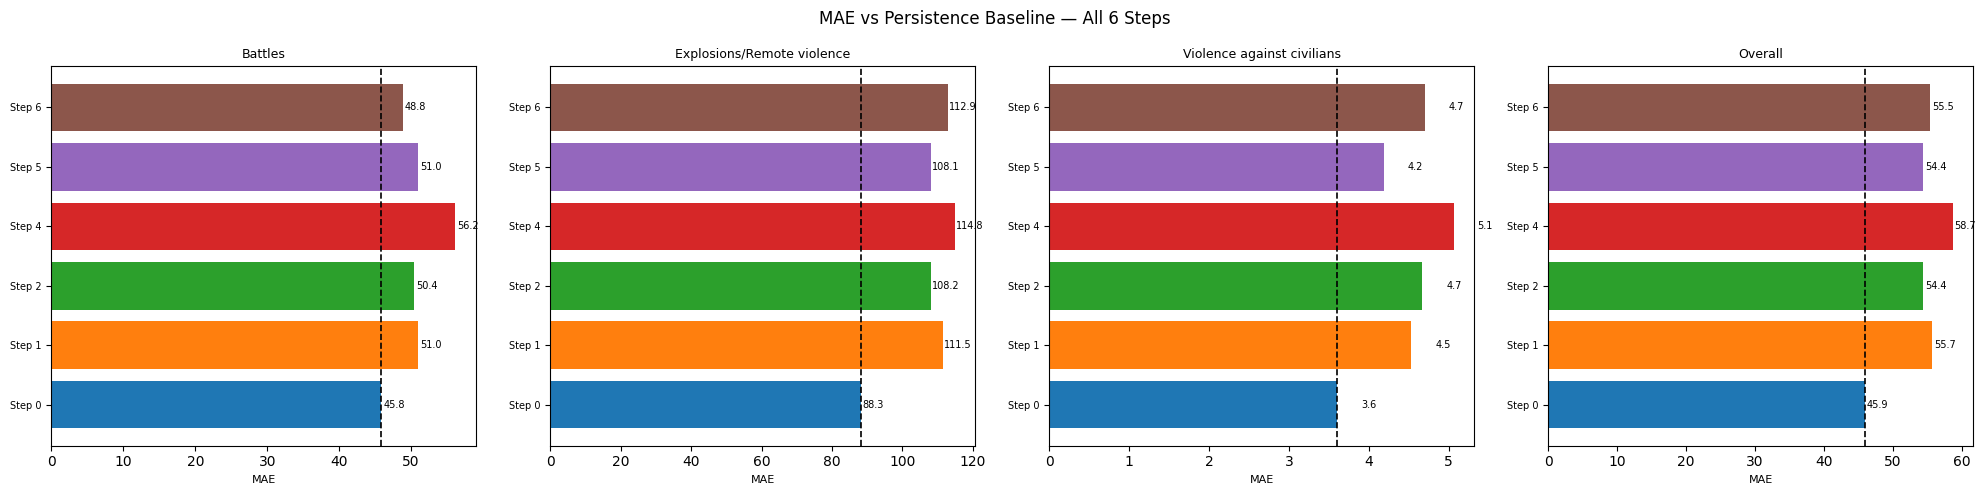

Saved: outputs/figures/improvements_6_summary.png


In [33]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('MAE vs Persistence Baseline — All 6 Steps', fontsize=12)

cols_plot = settings.targets + ['Overall']
colors = plt.cm.tab10.colors

for ax, col in zip(axes, cols_plot):
    vals  = summary[col]
    pbase = vals.iloc[0]  # persistence
    bars  = ax.barh(range(len(vals)), vals.values, color=colors[:len(vals)])
    ax.axvline(pbase, color='black', linestyle='--', linewidth=1.2, label='Persistence')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([s.split('—')[0].strip() for s in vals.index], fontsize=7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('MAE', fontsize=8)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=7)

plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/improvements_6_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/improvements_6_summary.png')

---
# V3+: Trajectory, Log-Target, Two-Stage Model


# V3 Experiments — Trajectory, Log-Target, Two-Stage Model

| # | Improvement | Description |
|---|-------------|-------------|
| 1 | **Two-stage model** | Binary onset classifier (LGBM) × Tweedie intensity regressor |
| 2 | **Stratified evaluation** | always-active / sporadic / dormant region tiers |
| 3 | **Per-horizon MAE** | How accuracy degrades over the 6-month holdout |
| 4 | **Trajectory features** | Slope and acceleration of target lag series |
| 7 | **Log-target** | Train on log1p(Y), evaluate in raw scale |
| 9 | **Neighbour trajectory** | Slope of neighbour event counts |

**Baseline for all comparisons**: V2 LGBM-Tweedie `+Engineered` (MAE ≈ 53).

All utility functions live in `utils/` — this notebook only orchestrates and visualises.

In [34]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
pass  # chdir removed (already set by first setup cell)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

from utils.preprocessing_v2 import prepare_enriched_pipeline_v2, build_feature_sets_v2
from utils.evaluators import find_top_regions, evaluate_model, stratify_regions
from utils.features.improved_features import add_trajectory_features
from models.two_stage import TwoStageModel
from config import settings

HOLDOUT  = 6
TARGETS  = settings.targets
TWEEDIE  = lambda: lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5, n_estimators=200, verbose=-1)
MSE_LGB  = lambda: lgb.LGBMRegressor(
    objective='regression', n_estimators=200, verbose=-1)

print('Imports OK')

Imports OK


In [35]:
print('Loading V2 enriched dataset...')
df = prepare_enriched_pipeline_v2(clean_data=False)
fs = build_feature_sets_v2(df)
BEST = fs['+Engineered']

top10 = find_top_regions(df, TARGETS, n=10)

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Top-10 regions: {top10}')
print(f'Best feature set (+Engineered): {len(BEST)} features')

Loading V2 enriched dataset...
Loading v2 enriched data from disk...


Dataset: 289,890 rows × 78 columns
Top-10 regions: ['UKR - Donetsk', 'UKR - Kharkiv', 'UKR - Sumy', 'SYR - Idlib', 'PSX - Gaza', 'UKR - Kherson', 'BRA - Rio de Janeiro', 'SYR - Aleppo', 'UKR - Zaporizhzhia', 'UKR - Luhansk']
Best feature set (+Engineered): 46 features


---
## Shared helper functions

Small local helpers used across multiple experiments. The heavy lifting
(trajectory features, two-stage model, stratification) is in `utils/`.

In [36]:
def _split(df, region):
    rdf = df[df['matched_admin1_id'] == region].sort_values('month_year').copy()
    if len(rdf) < HOLDOUT + 6:
        return None, None
    return rdf.iloc[:-HOLDOUT], rdf.iloc[-HOLDOUT:]


def _fit_predict(train, test, avail, target, factory, log_y=False):
    X_tr = train[avail].fillna(0)
    X_te = test[avail].fillna(0)
    y_tr = train[target].fillna(0)
    w    = train.get('importance_weight',
                     pd.Series(1.0, index=train.index)).fillna(1)
    if log_y:
        y_tr = np.log1p(y_tr)
    if y_tr.sum() == 0:
        return np.zeros(len(X_te))
    m = factory()
    try:
        m.fit(X_tr, y_tr, sample_weight=w)
    except (TypeError, Exception):
        m.fit(X_tr, y_tr)
    raw = m.predict(X_te)
    return np.maximum(0, np.expm1(raw) if log_y else raw)


def mean_mae(records):
    vals = [r for r in records if r is not None]
    return round(np.mean(vals), 2) if vals else np.nan


# Persistence reference for all comparisons
def persistence_mae(df, region, target):
    _, test = _split(df, region)
    if test is None:
        return None
    lag = f'{target} (t-1)'
    if lag not in test.columns:
        return None
    return mean_absolute_error(test[target].fillna(0), test[lag].fillna(0))


persist = {t: mean_mae([persistence_mae(df, r, t) for r in top10]) for t in TARGETS}
persist['Overall'] = round(np.mean(list(persist.values())), 2)
print('Persistence MAE (top-10 regions):')
for k, v in persist.items():
    print(f'  {k:35s}: {v:.2f}')

Persistence MAE (top-10 regions):
  Battles                            : 45.83
  Explosions/Remote violence         : 88.33
  Violence against civilians         : 3.60
  Overall                            : 45.92


---
## Items 4 & 9 — Conflict Trajectory + Neighbour Trajectory Features

Hypothesis: the *direction* of conflict (is it rising or falling?) is predictive
of the next month's count, beyond what the raw lag values tell the model.

**New features** (from `utils.features.improved_features.add_trajectory_features`):
- `{target}_slope(t-1)` = Y(t-1) − Y(t-2)  — first difference
- `{target}_accel(t-1)` = slope(t-1) − slope(t-2)  — second difference
- `{target}_nbr_slope(t-1)` = neighbour(t-1) − neighbour(t-2)  — regional trend

In [37]:
print('Adding trajectory features...')
df_traj, traj_cols = add_trajectory_features(df)
BEST_TRAJ = BEST + traj_cols

print(f'New trajectory features ({len(traj_cols)}):')
for c in traj_cols:
    print(f'  {c}')
print(f'\nFeature set size: {len(BEST)} → {len(BEST_TRAJ)}')

Adding trajectory features...
New trajectory features (9):
  Battles_slope(t-1)
  Battles_accel(t-1)
  Explosions/Remote violence_slope(t-1)
  Explosions/Remote violence_accel(t-1)
  Violence against civilians_slope(t-1)
  Violence against civilians_accel(t-1)
  Battles_nbr_slope(t-1)
  Explosions/Remote violence_nbr_slope(t-1)
  Violence against civilians_nbr_slope(t-1)

Feature set size: 46 → 55


In [38]:
# V2 reference on the same top-10 (re-run to ensure apples-to-apples)
print('Computing V2 LGBM-Tweedie +Engineered reference...')
v2ref = {t: mean_mae([evaluate_model(df, r, t, BEST, TWEEDIE)['mae']
                       if evaluate_model(df, r, t, BEST, TWEEDIE) else None
                       for r in top10])
         for t in TARGETS}
v2ref['Overall'] = round(np.mean(list(v2ref.values())), 2)

print('Running trajectory feature experiment...')
traj_r = {t: mean_mae([evaluate_model(df_traj, r, t, BEST_TRAJ, TWEEDIE)['mae']
                        if evaluate_model(df_traj, r, t, BEST_TRAJ, TWEEDIE) else None
                        for r in top10])
          for t in TARGETS}
traj_r['Overall'] = round(np.mean(list(traj_r.values())), 2)

print(f'\n{"Target":35s}  {"V2 Tweedie":>10}  {"+ Trajectory":>12}  {"Δ":>8}')
print('-' * 72)
for t in TARGETS + ['Overall']:
    v, n = v2ref[t], traj_r[t]
    d = n - v
    flag = '+' if d < 0 else '-'
    print(f'  {t:33s}  {v:>10.2f}  {n:>12.2f}  {d:>+8.2f} {flag}')
print('\n+ = improvement (lower MAE)')

Computing V2 LGBM-Tweedie +Engineered reference...


Running trajectory feature experiment...



Target                               V2 Tweedie  + Trajectory         Δ
------------------------------------------------------------------------
  Battles                                 50.98         51.54     +0.56 -
  Explosions/Remote violence             108.91        107.86     -1.05 +
  Violence against civilians               4.63          4.38     -0.25 +
  Overall                                 54.84         54.59     -0.25 +

+ = improvement (lower MAE)


---
## Item 7 — Log-Target Training

Train the regressor on `log1p(Y)`, then back-transform predictions with
`expm1`. This helps when:
- The target has a heavy right tail (a few months with extremely high counts)
- The model is evaluated with MAE (symmetric, sensitive to large errors)

Under log-space training, large counts receive proportionally less weight,
which can hurt or help depending on where the forecast errors are largest.

In [39]:
print('Running log-target experiment...')
log_r = {t: mean_mae([_fit_predict(*_split(df, r)[:2] if _split(df, r)[0] is not None else (None, None),
                       [p for p in BEST if p in df.columns], t, MSE_LGB, log_y=True)
                       for r in top10])
         if _split(df, top10[0])[0] is not None else np.nan
         for t in TARGETS}

# Cleaner version using a local eval function
def eval_log_target(region, target):
    train, test = _split(df, region)
    if train is None:
        return None
    avail = [p for p in BEST if p in df.columns]
    pred  = _fit_predict(train, test, avail, target, MSE_LGB, log_y=True)
    return mean_absolute_error(test[target].fillna(0), pred)

log_r = {t: mean_mae([eval_log_target(r, t) for r in top10]) for t in TARGETS}
log_r['Overall'] = round(np.mean(list(log_r.values())), 2)

print(f'\n{"Target":35s}  {"V2 Tweedie":>10}  {"Log-target":>10}  {"Δ":>8}')
print('-' * 72)
for t in TARGETS + ['Overall']:
    v, n = v2ref[t], log_r[t]
    d = n - v
    flag = '+' if d < 0 else '-'
    print(f'  {t:33s}  {v:>10.2f}  {n:>10.2f}  {d:>+8.2f} {flag}')

Running log-target experiment...



Target                               V2 Tweedie  Log-target         Δ
------------------------------------------------------------------------
  Battles                                 50.98       49.99     -0.99 +
  Explosions/Remote violence             108.91      140.23    +31.32 -
  Violence against civilians               4.63        4.54     -0.09 +
  Overall                                 54.84       64.92    +10.08 -


---
## Item 1 — Two-Stage Model (Classifier × Regressor)

Many admin-1 regions are dormant in some months and active in others.
A single Tweedie model has to simultaneously learn *when* conflict starts and
*how intense* it is — arguably two distinct problems.

**Architecture** (`models.two_stage.TwoStageModel`):
1. **Stage 1**: `LGBMClassifier` estimates P(conflict active this month)
2. **Stage 2**: `LGBMTweedie` estimates E[count | active], trained on active months only
3. **Output**: P(active) × E[count | active]

Edge cases: always-active regions skip Stage 1; always-dormant regions predict 0.

In [40]:
def eval_two_stage(region, target):
    train, test = _split(df, region)
    if train is None:
        return None
    avail = [p for p in BEST if p in df.columns]
    Xtr = train[avail].fillna(0).values
    Xte = test[avail].fillna(0).values
    ytr = train[target].fillna(0).values
    yte = test[target].fillna(0).values
    w   = train.get('importance_weight',
                    pd.Series(1.0, index=train.index)).fillna(1).values
    m = TwoStageModel().fit(Xtr, ytr, w)
    return mean_absolute_error(yte, np.maximum(0, m.predict(Xte)))


print('Running two-stage model experiment...')
ts_r = {t: mean_mae([eval_two_stage(r, t) for r in top10]) for t in TARGETS}
ts_r['Overall'] = round(np.mean(list(ts_r.values())), 2)

print(f'\n{"Target":35s}  {"V2 Tweedie":>10}  {"Two-stage":>10}  {"Δ":>8}')
print('-' * 72)
for t in TARGETS + ['Overall']:
    v, n = v2ref[t], ts_r[t]
    d = n - v
    flag = '+' if d < 0 else '-'
    print(f'  {t:33s}  {v:>10.2f}  {n:>10.2f}  {d:>+8.2f} {flag}')

Running two-stage model experiment...



Target                               V2 Tweedie   Two-stage         Δ
------------------------------------------------------------------------
  Battles                                 50.98       57.32     +6.34 -
  Explosions/Remote violence             108.91      151.81    +42.90 -
  Violence against civilians               4.63        5.20     +0.57 -
  Overall                                 54.84       71.44    +16.60 -


---
## Combined — Two-Stage + Trajectory + Log-Target

Best of all three improvements together:
- Two-stage architecture (Stage 1 classifier)
- Trajectory features as input to both stages
- Log1p target for Stage 2 intensity regressor

In [41]:
def eval_combined(region, target):
    """Two-stage using trajectory features; Stage 2 trains on log1p(Y)."""
    train, test = _split(df_traj, region)
    if train is None:
        return None
    avail = [p for p in BEST_TRAJ if p in df_traj.columns]
    Xtr = train[avail].fillna(0).values
    Xte = test[avail].fillna(0).values
    ytr = train[target].fillna(0).values
    yte = test[target].fillna(0).values
    w   = train.get('importance_weight',
                    pd.Series(1.0, index=train.index)).fillna(1).values

    # Stage 1: classifier
    clf = lgb.LGBMClassifier(n_estimators=200, verbose=-1)
    clf.fit(Xtr, (ytr > 0).astype(int), sample_weight=w)
    prob = clf.predict_proba(Xte)[:, 1]

    # Stage 2: log-target intensity on active months
    mask = ytr > 0
    if mask.sum() >= 10:
        reg = lgb.LGBMRegressor(objective='regression', n_estimators=200, verbose=-1)
        reg.fit(Xtr[mask], np.log1p(ytr[mask]), sample_weight=w[mask])
        intens = np.maximum(0, np.expm1(reg.predict(Xte)))
    else:
        intens = np.zeros(len(Xte))

    return mean_absolute_error(yte, np.maximum(0, prob * intens))


print('Running combined experiment...')
comb_r = {t: mean_mae([eval_combined(r, t) for r in top10]) for t in TARGETS}
comb_r['Overall'] = round(np.mean(list(comb_r.values())), 2)

print(f'\n{"Target":35s}  {"V2 Tweedie":>10}  {"Combined":>10}  {"Δ":>8}')
print('-' * 72)
for t in TARGETS + ['Overall']:
    v, n = v2ref[t], comb_r[t]
    d = n - v
    flag = '+' if d < 0 else '-'
    print(f'  {t:33s}  {v:>10.2f}  {n:>10.2f}  {d:>+8.2f} {flag}')

Running combined experiment...



Target                               V2 Tweedie    Combined         Δ
------------------------------------------------------------------------
  Battles                                 50.98      192.29   +141.31 -
  Explosions/Remote violence             108.91      221.08   +112.17 -
  Violence against civilians               4.63        7.60     +2.97 -
  Overall                                 54.84      140.32    +85.48 -


---
## Item 2 — Stratified Evaluation

Aggregate MAE across all regions masks very different failure modes:
- **Always-active** regions (e.g. Ukraine, Syria): model needs to track large counts
- **Sporadic** regions: onset prediction matters as much as intensity
- **Dormant** regions: near-zero baseline makes MAE trivially low

`stratify_regions()` classifies regions by training-period activity level
and returns up to 8 per tier for evaluation.

In [42]:
print('Stratifying regions...')
tiers = stratify_regions(df, n=8)

for tier_name, regions in tiers.items():
    if not regions:
        continue
    print(f'\n  Tier: {tier_name.upper()}  ({len(regions)} regions)')
    print(f'  Regions: {regions[:4]}{"..." if len(regions)>4 else ""}')

    for label, eval_fn in [
        ('Persistence',  lambda r, t: persistence_mae(df, r, t)),
        ('V2 Tweedie',   lambda r, t: (evaluate_model(df, r, t, BEST, TWEEDIE) or {}).get('mae')),
        ('Two-stage',    lambda r, t: eval_two_stage(r, t)),
        ('Log-target',   lambda r, t: eval_log_target(r, t)),
        ('+ Trajectory', lambda r, t: (evaluate_model(df_traj, r, t, BEST_TRAJ, TWEEDIE) or {}).get('mae')),
    ]:
        maes = [eval_fn(r, t) for r in regions for t in TARGETS]
        maes = [x for x in maes if x is not None]
        if maes:
            print(f'    {label:15s}: {np.mean(maes):.2f}')

Stratifying regions...



  Tier: ALWAYS_ACTIVE  (8 regions)
  Regions: ['UKR - Donetsk', 'SYR - Idlib', 'BRA - Rio de Janeiro', 'SYR - Aleppo']...
    Persistence    : 40.40


    V2 Tweedie     : 43.01


    Two-stage      : 45.31


    Log-target     : 50.42


...

    + Trajectory   : 2.54

  Tier: DORMANT  (8 regions)
  Regions: ['JAM - Saint Mary', 'BFA - Centre-ouest', 'NPL - Sudurpashchim', 'BIH - Zenica-Doboj Canton']...
    Persistence    : 0.28


    V2 Tweedie     : 0.41


    Two-stage      : 0.36


    Log-target     : 0.30


    + Trajectory   : 0.37


---
## Item 3 — Per-Horizon MAE

A single holdout MAE collapses 6 months into one number. The first month
(1-step-ahead) benefits from a fresh lag; by month 6 the model is working
with stale signals. Tracking MAE by horizon reveals how quickly accuracy
degrades — an important property for operational forecasting.

In [43]:
def eval_per_horizon(df_src, region, target, preds, factory=TWEEDIE):
    train, test = _split(df_src, region)
    if train is None:
        return None
    avail = [p for p in preds if p in df_src.columns]
    pred = _fit_predict(train, test, avail, target, factory)
    return np.abs(test[target].fillna(0).values - pred)


h_persist = np.zeros(HOLDOUT)
h_v2      = np.zeros(HOLDOUT)
h_traj    = np.zeros(HOLDOUT)
counts    = 0

for region in top10:
    for target in TARGETS:
        ep   = eval_per_horizon(df,      region, target, BEST)
        et   = eval_per_horizon(df_traj, region, target, BEST_TRAJ)
        _, test = _split(df, region)
        if ep is None or et is None or test is None:
            continue
        lag = f'{target} (t-1)'
        if lag not in test.columns:
            continue
        persist_err = np.abs(test[target].fillna(0).values - test[lag].fillna(0).values)
        h_persist += persist_err
        h_v2      += ep
        h_traj    += et
        counts    += 1

if counts:
    h_persist /= counts
    h_v2      /= counts
    h_traj    /= counts
    horizon_df = pd.DataFrame({
        'Horizon': range(1, HOLDOUT + 1),
        'Persistence': h_persist,
        'V2 Tweedie':  h_v2,
        '+ Trajectory': h_traj,
    }).set_index('Horizon')
    print(horizon_df.round(2).to_string())

         Persistence  V2 Tweedie  + Trajectory
Horizon                                       
1              44.43       54.06         63.98
2              44.63       61.56         67.60
3              50.83       48.60         36.24
4              28.10       49.79         49.11
5              23.97       64.79         68.86
6              83.57       50.22         41.77


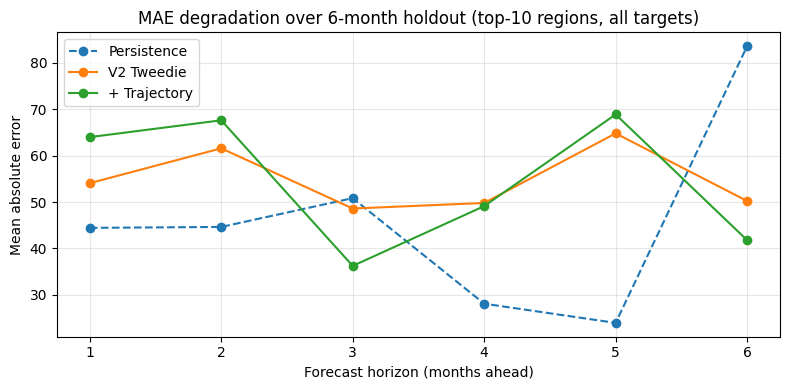

Saved: outputs/figures/improvements_7_horizon.png


In [44]:
if counts:
    fig, ax = plt.subplots(figsize=(8, 4))
    for col, ls in [('Persistence', '--'), ('V2 Tweedie', '-'), ('+ Trajectory', '-')]:
        ax.plot(horizon_df.index, horizon_df[col], marker='o', linestyle=ls, label=col)
    ax.set_xlabel('Forecast horizon (months ahead)')
    ax.set_ylabel('Mean absolute error')
    ax.set_title('MAE degradation over 6-month holdout (top-10 regions, all targets)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    os.makedirs('outputs/figures', exist_ok=True)
    plt.savefig('outputs/figures/improvements_7_horizon.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/figures/improvements_7_horizon.png')

---
## Final Summary

In [45]:
rows = [
    ('Persistence (floor)',        persist),
    ('V2 LGBM-Tweedie (baseline)', v2ref),
    ('+ Trajectory feats (4+9)',   traj_r),
    ('Log-target (7)',             log_r),
    ('Two-stage (1)',              ts_r),
    ('Combined (1+4+7+9)',         comb_r),
]

print(f'{"Method":30s}  {"Battles":>8}  {"Explosions":>10}  {"VaC":>6}  {"Overall":>8}  {"vs V2":>8}')
print('-' * 78)
v2_overall = v2ref['Overall']
for name, d in rows:
    ov = d['Overall']
    dv = ov - v2_overall
    flag = '~' if name.startswith('V2') else ('+' if dv < 0 else '-')
    print(f'  {name:28s}  {d["Battles"]:>8.2f}  '
          f'{d["Explosions/Remote violence"]:>10.2f}  '
          f'{d["Violence against civilians"]:>6.2f}  '
          f'{ov:>8.2f}  {dv:>+7.2f} {flag}')

# Save
result_rows = [{'method': name, **d} for name, d in rows]
os.makedirs('outputs', exist_ok=True)
pd.DataFrame(result_rows).to_csv('outputs/improvements_7_results.csv', index=False)
print('\nSaved: outputs/improvements_7_results.csv')

Method                           Battles  Explosions     VaC   Overall     vs V2
------------------------------------------------------------------------------
  Persistence (floor)              45.83       88.33    3.60     45.92    -8.92 +
  V2 LGBM-Tweedie (baseline)       50.98      108.91    4.63     54.84    +0.00 ~
  + Trajectory feats (4+9)         51.54      107.86    4.38     54.59    -0.25 +
  Log-target (7)                   49.99      140.23    4.54     64.92   +10.08 -
  Two-stage (1)                    57.32      151.81    5.20     71.44   +16.60 -
  Combined (1+4+7+9)              192.29      221.08    7.60    140.32   +85.48 -

Saved: outputs/improvements_7_results.csv
